In [7]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

### Exploring files

In [3]:
datapath = Path.cwd()/'data/movielens'

In [4]:
for file in datapath.iterdir():
    print(file.name)

README.txt
train.csv
ratings.csv
links.csv
movies.csv
genome-scores.csv
test.csv
genome-tags.csv
tags.csv


### EXPLORE RATINGS DATA - 32M RATING FROM 1995 TO 2023

In [9]:
rating_df = pd.read_csv(datapath/'ratings.csv')

In [10]:
rating_df['timestamp']  = pd.to_datetime(rating_df["timestamp"], unit='s')
rating_df.sort_values(by='timestamp', inplace=True)

In [11]:
print(rating_df.columns)
print(rating_df.shape)

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')
(33832162, 4)


In [12]:
rating_df.sort_values(by='timestamp', inplace=True)
rating_df.head(5)

,userId,movieId,rating,timestamp
15254009,149954,1176,4.0,1995-01-09 11:46:44
9617113,94532,21,3.0,1995-01-09 11:46:49
9617119,94532,47,5.0,1995-01-09 11:46:49
9617162,94532,1079,3.0,1995-01-09 11:46:49
16958936,166476,52,4.0,1996-01-29 00:00:00


In [13]:
rating_df.tail(5)

,userId,movieId,rating,timestamp
22026732,214831,281864,1.5,2023-07-20 08:24:00
29836322,291554,5282,3.5,2023-07-20 08:29:19
29836181,291554,1201,4.5,2023-07-20 08:41:31
29836625,291554,215173,4.5,2023-07-20 08:43:16
5623443,54638,288265,4.0,2023-07-20 08:53:33


### WORKING WITH A SUBSET OF DATA - 2022 to 2023
* #### 17888 unique users and 48546 unique movies
* #### There are 4991 users who wrote lesser than 5 reviews
* #### There are 38197 movies which got lesser than 5 reviews

In [14]:
small_rating_df = rating_df[rating_df['timestamp'] > '01-01-2022']
small_rating_df.shape

(1515971, 4)

In [15]:
n_users = len(small_rating_df['userId'].unique())
n_items = len(small_rating_df['movieId'].unique())
print(f"{n_users} unique users and {n_items} unique movies")

17888 unique users and 48546 unique movies


Text(0, 0.5, 'Counts')

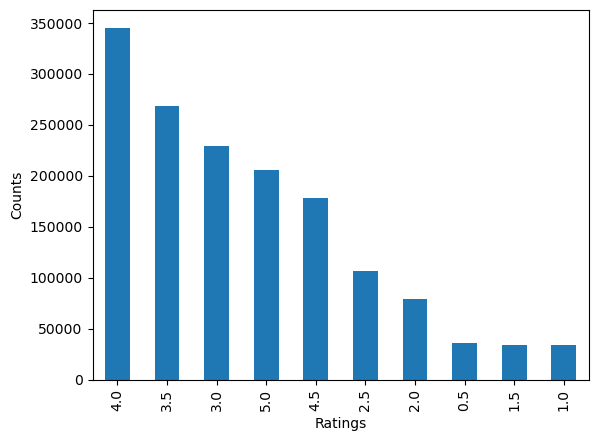

In [16]:
small_rating_df["rating"].value_counts().plot(kind='bar')
plt.xlabel("Ratings")
plt.ylabel("Counts")

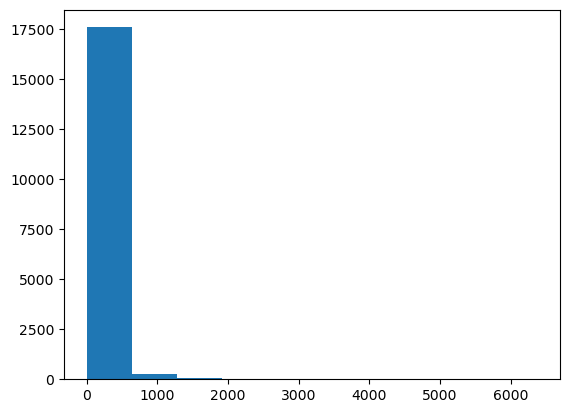

In [17]:
plt.hist(small_rating_df.groupby(by='userId')['rating'].count().values) 

plt.show()

In [18]:
m  = sum(small_rating_df.groupby(by='userId')['rating'].count() < 5)
print(f"There are {m} users who wrote lesser than 5 reviews")

There are 3220 users who wrote lesser than 5 reviews


In [19]:
m  = sum(small_rating_df.groupby(by='movieId')['rating'].count() < 5)
print(f"There are {m} movies which got lesser than 5 reviews")

There are 32398 movies which got lesser than 5 reviews


### PREPARE TRAIN AND TEST DATASET - 10984 users and 36393 movies in training process

In [8]:
n = small_rating_df.shape[0]
n_train = int(n*0.5)

train_df = small_rating_df.iloc[:n_train]
test_df = small_rating_df.iloc[n_train: ]

NameError: name 'small_rating_df' is not defined

In [21]:
print(train_df.shape)
print(test_df.shape)

(757985, 4)
(757986, 4)


In [22]:
unique_movies = set(train_df['movieId'].unique())
unique_users = set(train_df['userId'].unique())

In [25]:
print(f"Train Data: {(len(unique_users))} users and {len(unique_movies)} movies")

Train Data: 10984 users and 36393 movies


In [26]:
test_df = test_df[test_df['movieId'].isin(unique_movies)]
test_df = test_df[test_df['userId'].isin(unique_users)]

In [27]:
print(test_df.shape)

(156546, 4)


In [28]:
train_df.columns = ['userId', 'productId', 'rating', 'timestamp']
test_df.columns = ['userId', 'productId', 'rating', 'timestamp']

In [29]:
train_df.to_csv("data/movielens/train.csv")
test_df.to_csv("data/movielens/test.csv")

### TO BE DELETED LATER

In [13]:
from MF_ALS.architecture import Encoder, ALSModelTrainer, ALSInference
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from multiprocessing import Pool, shared_memory
import time
import pickle
from functools import partial

In [2]:
train_df = pd.read_csv("data/movielens/train.csv", index_col=0)

In [3]:
small_df_train = train_df.iloc[0:1000]
small_df_val =  train_df.iloc[1000:10000]
print(small_df_train['userId'].unique().shape)
print(small_df_train['productId'].unique().shape)

(51,)
(843,)


In [4]:
trainer = ALSModelTrainer(regulariser=10, train_data=small_df_train, validation_data=small_df_val, dim=15)

In [5]:
trainer.validation_data.shape

(88, 4)

In [6]:
trainer.train(T=20)

At epoch - 0: max user diff norm: 331.7247109996799 | max user bias diff : 1.5054988058937462
At epoch - 0: max item diff norm: 2.9130793732748064 | max item bias diff : 82.98040410155117
At end of epoch 0| validation error: 3.466700790768441 | train error: 4.368415934798343



/home/arnabroy/Workspace/recommendation_system/MF_ALS/architecture.py:338: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['prediction'] = data.apply(lambda x: predict(x['userId'], x['productId']), axis=1)


At epoch - 1: max user diff norm: 329.28968187467456 | max user bias diff : 4.75032526233763
At epoch - 1: max item diff norm: 10.458582339657053 | max item bias diff : 83.23576786613559
At end of epoch 1| validation error: 5.016738477677541 | train error: 8.173259505386405

At epoch - 2: max user diff norm: 187.49740284737965 | max user bias diff : 10.318876319529092
At epoch - 2: max item diff norm: 11.179910294329234 | max item bias diff : 110.99251062480047
At end of epoch 2| validation error: 7.608020914636494 | train error: 7.343583598456117

At epoch - 3: max user diff norm: 160.57253704794573 | max user bias diff : 4.118625355414877
At epoch - 3: max item diff norm: 13.397662085333891 | max item bias diff : 109.86145458482254
At end of epoch 3| validation error: 3.382586180694342 | train error: 4.031317767392725

At epoch - 4: max user diff norm: 1052.7991195082595 | max user bias diff : 14.832410590625184
At epoch - 4: max item diff norm: 12.30111605891632 | max item bias diff

In [9]:
with open("models/MF_ALS/mftrainer_best.pkl", "rb") as f:
    best = pickle.load(f)
    f.close()

In [12]:
movies = pd.read_csv("data/movielens/movies.csv")


In [26]:
trainer.validation_data[trainer.validation_data['userId'] == 163322]

,userId,productId,rating,timestamp,prediction
16632571,163322,3825,1.5,2022-01-01 01:51:15,0.5
16632672,163322,5449,3.0,2022-01-01 01:59:57,0.5
16632618,163322,4340,1.5,2022-01-01 02:02:45,0.5
16632605,163322,4226,3.0,2022-01-01 02:04:31,5.0
16632149,163322,39,2.5,2022-01-01 03:54:58,5.0
16632423,163322,2302,3.5,2022-01-01 03:55:25,5.0
16632221,163322,485,3.0,2022-01-01 03:55:41,5.0
16632262,163322,899,2.0,2022-01-01 04:28:58,5.0
16632250,163322,733,4.0,2022-01-01 04:30:25,5.0
16632822,163322,51662,3.5,2022-01-01 04:31:57,5.0


In [25]:
trainer.validation_data

,userId,productId,rating,timestamp,prediction
16632571,163322,3825,1.5,2022-01-01 01:51:15,0.5
13208383,129814,2712,4.0,2022-01-01 01:56:50,5.0
16632672,163322,5449,3.0,2022-01-01 01:59:57,0.5
16632618,163322,4340,1.5,2022-01-01 02:02:45,0.5
16632605,163322,4226,3.0,2022-01-01 02:04:31,5.0
...,...,...,...,...,...
12096569,119112,2291,4.5,2022-01-03 02:04:18,5.0
21399296,208782,116823,2.5,2022-01-03 04:00:27,5.0
20042571,195917,116823,2.0,2022-01-03 04:01:07,5.0
20042591,195917,135133,1.5,2022-01-03 06:01:10,5.0


In [7]:
trainer.model.predict_rating(
    userid=trainer.enc.user_id[119112],
    itemid=trainer.enc.item_id[1136]
)

array([2.52038428])

In [6]:
def predict(userId, productId):
    user = trainer.enc.user_id[userId],
    item = trainer.enc.item_id[productId]
    rating = trainer.model.predict_rating (user, item)[0]
    rating = min(rating, 5.0)
    rating = max(rating, 0.0)
    return rating

In [ ]:
small_df_train['prediction'] = small_df_train.apply(lambda x: predict(x['userId'], x['productId']), axis=1)

/tmp/ipykernel_23431/272506038.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  small_df['prediction'] = small_df.apply(lambda x: predict(x['userId'], x['productId']), axis=1)


In [ ]:
np.sum((small_df_train.rating.values - small_df_train.prediction.values)**2)/small_df_train.shape[0]

3.972506060153609

In [4]:
inference = ALSInference()

In [9]:
itemarray = np.array(list(inference.enc.id_item.keys()))

In [11]:
def predict(num1, num2):
    return num2/num1

In [15]:
np.apply_along_axis(func1d=partial(predict, 100), arr=itemarray, axis=0)

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99, 1.  , 1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09,
       1.1 , 1.11, 1.12, 1.13, 1.14, 1.15, 1.16, 1.17, 1.18, 1.19, 1.2 ,
       1.21, 1.22, 1.23, 1.24, 1.25, 1.26, 1.27, 1.28, 1.29, 1.3 , 1.31,
       1.32, 1.33, 1.34, 1.35, 1.36, 1.37, 1.38, 1.39, 1.4 , 1.41, 1.42,
       1.43, 1.44, 1.45, 1.46, 1.47, 1.48, 1.49, 1.

In [17]:
inference.enc.user_id

{248294: 0,
 177726: 1,
 286893: 2,
 321454: 3,
 84092: 4,
 119112: 5,
 205303: 6,
 163322: 7,
 178084: 8,
 102750: 9,
 312852: 10,
 184788: 11,
 95143: 12,
 20623: 13,
 269984: 14,
 145730: 15,
 250148: 16,
 169466: 17,
 198115: 18,
 146124: 19,
 54846: 20,
 317884: 21,
 129814: 22,
 69478: 23,
 38404: 24,
 322364: 25,
 10652: 26,
 327439: 27,
 165514: 28,
 127871: 29,
 304845: 30,
 118870: 31,
 16020: 32,
 192393: 33,
 323074: 34,
 8942: 35,
 257016: 36,
 177638: 37,
 208782: 38,
 307020: 39,
 299530: 40,
 229687: 41,
 74363: 42,
 269710: 43,
 126357: 44,
 195917: 45,
 248116: 46,
 248317: 47,
 39476: 48,
 184152: 49,
 24969: 50}